In [2]:
import mne
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import pandas as pd

bands_ce ={'Delta':(1.5,6),
        'Theta':(6,8.5),
        'Alpha-1':(8.5,10.5),
        'Alpha-2':(10.5,12.5),
        'Beta1':(12.5,18.5),
        'Beta2':(18.5,21),
        'Beta3':(21,30),
        'Gamma':(30,40)
        }

# APPLEE in centers

### Get PSD

z-score

In [19]:
psd_cl = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_Chile_rs_scorEpochs_zscore_long.feather")
psd_ar = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_Argentina_rs_scorEpochs_zscore_long.feather")
psd_srm = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_Oslo_resteyesc_scorEpochs_zscore_long.feather")
psd_bio = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_Medellin_hd_CE_scorEpochs_zscore_long.feather")
psd_por = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_Medellin_ld_CE_scorEpochs_zscore_long.feather") 
psd_chmbp = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_Cuba_CE_scorEpochs_zscore_long.feather")
psd_poland = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_Poland_rest_scorEpochs_zscore_long.feather")
psd_korean = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_CAUEEG_rs_scorEpochs_zscore_long.feather")
psd_Dortmund = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_Dortmund_EyesClosed_scorEpochs_zscore_long.feather") 
psd_greece = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_GREECE_eyesclosed_scorEpochs_zscore_long.feather")
psd_Madrid = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\psd_Madrid_rest_scorEpochs_zscore_long.feather")
psd_korean['Sensors'] = psd_korean['Sensors'].replace({'T5': 'P7', 'T6': 'P8'})
psd_greece['Sensors'] = psd_greece['Sensors'].replace({'T5': 'P7', 'T6': 'P8'})

In [20]:
QA_Dortmund = pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\Quality_data\0.7_scorEpochs\QC_Dortmund.xlsx")
QA_AR = pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\Quality_data\0.7_scorEpochs\QC_Argentina.xlsx")
QA_CL = pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\Quality_data\0.7_scorEpochs\QC_Chile.xlsx")
QA_cuba = pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\Quality_data\0.7_scorEpochs\QC_Cuba.xlsx")
QA_Med_ld = pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\Quality_data\0.7_scorEpochs\QC_Medellin_ld.xlsx")
QA_Med_hd = pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\Quality_data\0.7_scorEpochs\QC_Medellin_hd.xlsx")
QA_CAUEEG = pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\Quality_data\0.7_scorEpochs\QC_CAUEEG.xlsx")
QA_SRM = pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\Quality_data\0.7_scorEpochs\QC_Oslo.xlsx")
QA_poland = pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\Quality_data\0.7_scorEpochs\QC_Poland.xlsx")
QA_greece = pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\Quality_data\0.7_scorEpochs\QC_GREECE.xlsx")

In [21]:
subj_drop_Dortmund = QA_Dortmund[QA_Dortmund['len_epochs'] < 24]['subject']
subj_drop_AR = QA_AR[QA_AR['len_epochs'] < 24]['subject']
subj_drop_CL = QA_CL[QA_CL['len_epochs'] < 24]['subject']
subj_drop_cuba = QA_cuba[QA_cuba['len_epochs'] < 24]['subject']
subj_drop_Med_ld = QA_Med_ld[QA_Med_ld['len_epochs'] < 24]['subject']
subj_drop_Med_hd = QA_Med_hd[QA_Med_hd['len_epochs'] < 24]['subject']
subj_drop_CAUEEG = QA_CAUEEG[QA_CAUEEG['len_epochs'] < 24]['subject']
subj_drop_SRM = QA_SRM[QA_SRM['len_epochs'] < 24]['subject']
subj_drop_poland = QA_poland[QA_poland['len_epochs'] < 24]['subject']
subj_drop_greece = QA_greece[QA_greece['len_epochs'] < 24]['subject']

In [22]:
print("subject deleted Dortmund: ", len(subj_drop_Dortmund))
print("subject deleted AR: ", len(subj_drop_AR))
print("subject deleted CL: ", len(subj_drop_CL))
print("subject deleted cuba: ", len(subj_drop_cuba))
print("subject deleted Med_ld: ", len(subj_drop_Med_ld))
print("subject deleted Med_hd: ", len(subj_drop_Med_hd))
print("subject deleted CAUEEG: ", len(subj_drop_CAUEEG))
print("subject deleted SRM: ", len(subj_drop_SRM))
print("subject deleted poland: ", len(subj_drop_poland))
print("subject deleted greece: ", len(subj_drop_greece))

subject deleted Dortmund:  1
subject deleted AR:  0
subject deleted CL:  0
subject deleted cuba:  0
subject deleted Med_ld:  0
subject deleted Med_hd:  0
subject deleted CAUEEG:  39
subject deleted SRM:  0
subject deleted poland:  0
subject deleted greece:  0


In [23]:
# Filtrar el DataFrame eliminando esos sujetos
psd_Dortmund = psd_Dortmund[~psd_Dortmund['subject'].isin(subj_drop_Dortmund)]
psd_CAUEEG = psd_korean[~psd_korean['subject'].isin(subj_drop_CAUEEG)]

In [24]:
psd_bio_ctr = psd_bio[(psd_bio['group'] == 'CTR') | (psd_bio['group'] == 'G2')].reset_index(drop=True)
psd_bio_dta = psd_bio[(psd_bio['group'] == 'DTA')].reset_index(drop=True)
psd_bio_mci = psd_bio[(psd_bio['group'] == 'DCL') ].reset_index(drop=True)
psd_por_ctr = psd_por[(psd_por['group'] == 'CTR') | (psd_por['group'] == 'GU')].reset_index(drop=True)
psd_por_mci = psd_por[(psd_por['group'] == 'DCL')].reset_index(drop=True)
psd_korean_hc= psd_korean[psd_korean['group']== 'HC'].reset_index(drop=True)
psd_korean_mci = psd_korean[psd_korean['group']== 'MCI'].reset_index(drop=True)
psd_greece_hc= psd_greece[psd_greece['group']== 'HC'].reset_index(drop=True)
psd_madrid_hc = psd_Madrid[psd_Madrid['group']== 'HC'].reset_index(drop=True)
psd_madrid_mci = psd_Madrid[psd_Madrid['group']== 'MCI'].reset_index(drop=True)

In [25]:
print('subject CL :',len(psd_cl.subject.unique()))
print('subject AR :',len(psd_ar.subject.unique()))
print('subject SRM :',len(psd_srm.subject.unique()))
print('subject BIO CTR: ',len(psd_bio_ctr.subject.unique()))
print('subject BIO DTA: ',len(psd_bio_dta.subject.unique()))
print('subject BIO MCI: ',len(psd_bio_mci.subject.unique()))
print('subject POR CTR: ',len(psd_por_ctr.subject.unique()))
print('subject POR MCI: ',len(psd_por_mci.subject.unique()))
print('subject CHMBP: ',len(psd_chmbp.subject.unique()))
print('subject POLAND: ',len(psd_poland.subject.unique()))
print('subject KOREAN CTR: ',len(psd_korean_hc.subject.unique()))
print('subject DORTMUND: ',len(psd_Dortmund.subject.unique()))
print('subject GREECE: ',len(psd_greece_hc.subject.unique()))
print('subject MADRID HC: ',len(psd_madrid_hc.subject.unique()))
print('subject MADRID MCI: ',len(psd_madrid_mci.subject.unique()))
TOTAL_CTR =len(psd_cl.subject.unique())+len(psd_ar.subject.unique())+len(psd_srm.subject.unique())+len(psd_bio_ctr.subject.unique())+len(psd_por_ctr.subject.unique())+len(psd_korean_hc.subject.unique())+len(psd_chmbp.subject.unique())+len(psd_poland.subject.unique())+len(psd_greece_hc.subject.unique())+len(psd_Dortmund.subject.unique())+len(psd_madrid_hc.subject.unique())
TOTAL_MCI = len(psd_por_mci.subject.unique()) + len(psd_bio_mci.subject.unique()) + len(psd_korean[psd_korean['group']== 'MCI'].subject.unique()) + len(psd_madrid_mci.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)
print('TOTAL MCI:',TOTAL_MCI)


subject CL : 13
subject AR : 19
subject SRM : 111
subject BIO CTR:  72
subject BIO DTA:  8
subject BIO MCI:  12
subject POR CTR:  63
subject POR MCI:  8
subject CHMBP:  247
subject POLAND:  77
subject KOREAN CTR:  446
subject DORTMUND:  607
subject GREECE:  29
subject MADRID HC:  22
subject MADRID MCI:  34
TOTAL CONTROLES: 1706
TOTAL MCI: 464


In [26]:
## PSD - zscore 

freq_cl = psd_cl.freqs[0]
freq_ar = psd_ar.freqs[0]
freq_srm = psd_srm.freqs[0]

freq_bio_ctr= psd_bio_ctr.freqs[0]
freq_bio_dta= psd_bio_dta.freqs[0]
freq_bio_mci= psd_bio_mci.freqs[0]


freq_por_ctr =psd_por_ctr.freqs[0]
freq_por_mci =psd_por_mci.freqs[0]

freq_chmbp = psd_chmbp.freqs[0]
freq_poland = psd_poland.freqs[0]
freq_korean_hc = psd_korean_hc.freqs[0]
freq_Dortmund = psd_Dortmund.freqs[0]
freq_greece_hc = psd_greece_hc.freqs.iloc[0]
freq_madrid_hc = psd_madrid_hc.freqs.iloc[0]
freq_madrid_mci = psd_madrid_mci.freqs.iloc[0]

# Power Spectral Density -mean and std

psd_cl_mean = psd_cl.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_cl_std = psd_cl.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_ar_mean = psd_ar.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_ar_std = psd_ar.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_srm_mean = psd_srm.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_srm_std = psd_srm.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_bio_ctr_mean = psd_bio_ctr.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_bio_ctr_std = psd_bio_ctr.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_bio_mci_mean = psd_bio_mci.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_bio_mci_std = psd_bio_mci.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_bio_dta_mean = psd_bio_dta.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_bio_dta_std = psd_bio_dta.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_por_ctr_mean = psd_por_ctr.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_por_ctr_std = psd_por_ctr.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_por_mci_mean = psd_por_mci.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_por_mci_std = psd_por_mci.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_chmbp_mean = psd_chmbp.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_chmbp_std = psd_chmbp.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_poland_mean = psd_poland.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_poland_std = psd_poland.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_korean_ctr_mean = psd_korean_hc.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_korean_ctr_std = psd_korean_hc.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_Dortmund_mean = psd_Dortmund.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_Dortmund_std = psd_Dortmund.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_Greece_mean = psd_greece_hc.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_Greece_std = psd_greece_hc.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_Madrid_hc_mean = psd_madrid_hc.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_Madrid_hc_std = psd_madrid_hc.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

psd_Madrid_mci_mean = psd_madrid_mci.groupby('Sensors')['psd'].apply(lambda x: np.mean(np.stack(x), axis=0)).reset_index()
psd_Madrid_mci_std = psd_madrid_mci.groupby('Sensors')['psd'].apply(lambda x: np.std(np.stack(x), axis=0)).reset_index()

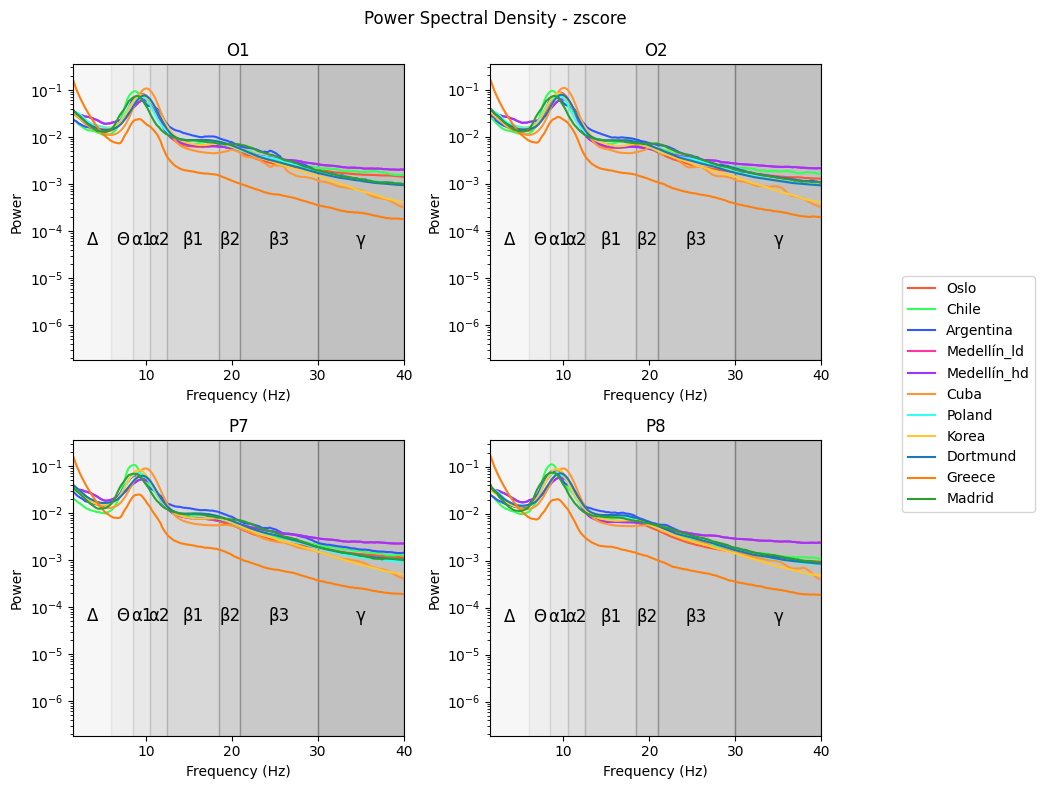

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define los nombres de los canales en el orden original
channel_names = ['O1','O2','P7','P8']#['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']

# Asocia cada banda a su símbolo griego correspondiente
band_symbols = {'Delta': 'Δ',
                'Theta': 'Θ',
                'Alpha-1': 'α1',
                'Alpha-2': 'α2',
                'Beta1': 'β1',
                'Beta2': 'β2',
                'Beta3': 'β3',
                'Gamma': 'γ'}

# Crea la figura y los subgráficos
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Aplanar los subgráficos para facilitar el acceso
axes = axes.flatten()

# Nueva selección de colores vívidos
vivid_colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A1', '#A133FF', '#FF9633', '#33FFF6','#FFC733']
grayscale_colors = np.linspace(0.9, 0.2, len(bands_ce))  # Escala de grises para las bandas

# Itera sobre cada canal en el orden original
for i, channel in enumerate(channel_names):
    # Extraer las frecuencias y los espectros promedio y std para el canal actual
    ## SRM in uV
    mean_psd_srm = psd_srm_mean[psd_srm_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_srm = psd_srm_std[psd_srm_std['Sensors'] == channel]['psd'].values[0]
    ## Portables in uV
    mean_psd_por = psd_bio_ctr_mean[psd_bio_ctr_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_por = psd_por_ctr_std[psd_por_ctr_std['Sensors'] == channel]['psd'].values[0]
    ## Chile
    mean_psd_cl = psd_cl_mean[psd_cl_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_cl = psd_cl_std[psd_cl_std['Sensors'] == channel]['psd'].values[0]
    ## Arge
    mean_psd_ar = psd_ar_mean[psd_ar_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_ar = psd_ar_std[psd_ar_std['Sensors'] == channel]['psd'].values[0]
    ## Medellín_hd
    mean_psd_bio = psd_bio_ctr_mean[psd_bio_ctr_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_bio = psd_bio_ctr_std[psd_bio_ctr_std['Sensors'] == channel]['psd'].values[0]
    ## Cuba
    mean_psd_chmbp = psd_chmbp_mean[psd_bio_ctr_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_chmbp = psd_chmbp_std[psd_bio_ctr_std['Sensors'] == channel]['psd'].values[0]
    ## Poland
    mean_psd_poland = psd_poland_mean[psd_poland_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_poland = psd_poland_std[psd_poland_std['Sensors'] == channel]['psd'].values[0]
    ## Korea
    mean_psd_korean = psd_korean_ctr_mean[psd_korean_ctr_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_korean = psd_korean_ctr_std[psd_korean_ctr_std['Sensors'] == channel]['psd'].values[0]
    ## Dortmund
    mean_psd_Dortmund = psd_Dortmund_mean[psd_Dortmund_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_Dortmund = psd_Dortmund_std[psd_Dortmund_std['Sensors'] == channel]['psd'].values[0]
    #Greece
    mean_psd_greece = psd_Greece_mean[psd_Greece_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_greece = psd_Greece_std[psd_Greece_std['Sensors'] == channel]['psd'].values[0]
    #Madrid
    mean_psd_madrid_hc = psd_Madrid_hc_mean[psd_Madrid_hc_mean['Sensors'] == channel]['psd'].values[0]
    std_psd_madrid_hc = psd_Madrid_hc_std[psd_Madrid_hc_std['Sensors'] == channel]['psd'].values[0]
    
    #Colocar fondos en escala de grises para cada banda usando los nombres con símbolos griegos
    for j, (band_name, (low_freq, high_freq)) in enumerate(bands_ce.items()):
        band_symbol = band_symbols[band_name]  # Obtener el símbolo griego
        axes[i].axvspan(low_freq, high_freq, color=str(grayscale_colors[j]), alpha=0.3)
        # Colocar el símbolo griego en la parte superior del gráfico
        axes[i].text((low_freq + high_freq) / 2,0.0001, band_symbol, 
             ha='center', va='top', fontsize=12, color='black')


    # Trazar el espectro promedio con colores vívidos
    axes[i].plot(freq_srm, mean_psd_srm, label='Oslo', color=vivid_colors[0])
    #axes[i].fill_between(freq_srm, mean_psd_srm + std_psd_srm, mean_psd_srm - std_psd_srm, color=vivid_colors[0], alpha=0.2, label='std-Oslo')
    axes[i].plot(freq_cl, mean_psd_cl, label='Chile', color=vivid_colors[1])
    #axes[i].fill_between(freq_cl, mean_psd_cl + std_psd_cl, mean_psd_cl - std_psd_cl, color=vivid_colors[1], alpha=0.2, label='std-Chile')
    axes[i].plot(freq_ar, mean_psd_ar, label='Argentina', color=vivid_colors[2])
    #axes[i].fill_between(freq_ar, mean_psd_ar + std_psd_ar, mean_psd_ar - std_psd_ar, color=vivid_colors[2], alpha=0.2, label='std-Argentina')
    axes[i].plot(freq_por_ctr, mean_psd_por, label='Medellín_ld', color=vivid_colors[3])
    #axes[i].fill_between(freq_por_ctr, mean_psd_por + std_psd_por, mean_psd_por - std_psd_por, color=vivid_colors[3], alpha=0.2, label='std-Medellín_ld')
    axes[i].plot(freq_bio_ctr, mean_psd_bio, label='Medellín_hd', color=vivid_colors[4])
    #axes[i].fill_between(freq_bio_ctr, mean_psd_bio + std_psd_bio, mean_psd_bio - std_psd_bio, color=vivid_colors[4], alpha=0.2, label='std-Medellín_hd')
    axes[i].plot(freq_chmbp, mean_psd_chmbp, label='Cuba', color=vivid_colors[5])
    #axes[i].fill_between(freq_chmbp, mean_psd_chmbp + std_psd_chmbp, mean_psd_chmbp - std_psd_chmbp, color=vivid_colors[5], alpha=0.2, label='std-Cuba')
    axes[i].plot(freq_poland, mean_psd_poland, label='Poland', color=vivid_colors[6])
    #axes[i].fill_between(freq_poland, mean_psd_poland + std_psd_poland, mean_psd_poland - std_psd_poland, color=vivid_colors[6], alpha=0.2, label='std -Poland')
    axes[i].plot(freq_korean_hc, mean_psd_korean, label='Korea', color=vivid_colors[7])
    #axes[i].fill_between(freq_korean_hc, mean_psd_korean + std_psd_korean, mean_psd_korean - std_psd_korean, color=vivid_colors[7], alpha=0.2, label='std -Korea')
    axes[i].plot(freq_Dortmund, mean_psd_Dortmund, label='Dortmund')
    #axes[i].fill_between(freq_Dortmund, mean_psd_Dortmund + std_psd_Dortmund, mean_psd_Dortmund - std_psd_Dortmund, alpha=0.2, label='std -Dortmund')
    axes[i].plot(freq_greece_hc, mean_psd_greece, label='Greece')
    #axes[i].fill_between(freq_greece_hc, mean_psd_greece + std_psd_greece, mean_psd_greece - std_psd_greece, alpha=0.2, label='std -Greece')
    axes[i].plot(freq_madrid_hc, mean_psd_madrid_hc, label='Madrid')
    
    
    # Configurar etiquetas y título
    axes[i].set_title(f'{channel}')
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Power')
    axes[i].set_xlim([1.5, 40])
    axes[i].set_yscale('log')
    #axes[i].grid(True)
    
fig.suptitle('Power Spectral Density - zscore')
# Ajustamos para dejar espacio en el lado derecho
plt.subplots_adjust(right=0.5)

# Obtenemos y creamos la leyenda
handles, labels = axes[0].get_legend_handles_labels()
unique_handles_labels = {label: handle for handle, label in zip(handles, labels)}
unique_handles = list(unique_handles_labels.values())
unique_labels = list(unique_handles_labels.keys())

# Ubicamos la leyenda en el lado derecho
fig.legend(unique_handles,
           unique_labels,
           loc='center left',       # 'upper left' si preferís que arranque desde arriba
           bbox_to_anchor=(0.9, 0.5), # Ancla en el borde derecho, centrada verticalmente
           ncol=1,                  # Cantidad de columnas en la leyenda
           fontsize=10)

# Ajustamos diseño para que no se sobrepongan cosas
plt.tight_layout(rect=[0, 0, 0.85, 1])  # deja espacio para la leyenda a la derecha
plt.savefig('D:\MulticentersEEG\graphs_thesis_LMZS\psd_zscore.pdf', dpi=600, format='pdf', bbox_inches='tight', transparent=True)
plt.show()

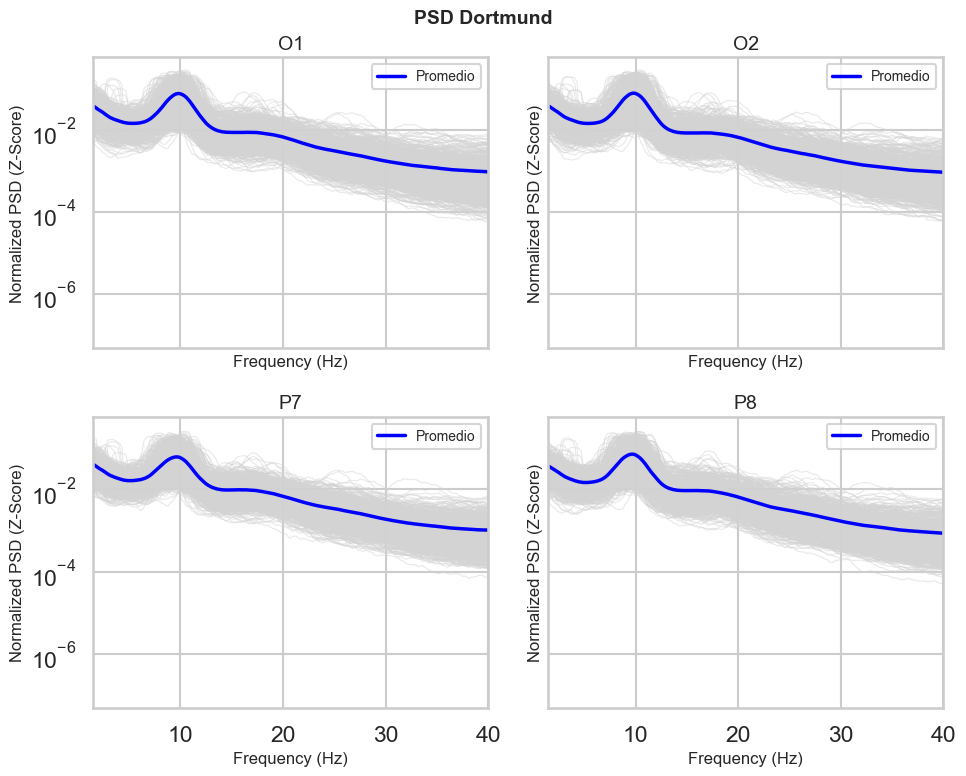

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Asegúrate de que las columnas 'freqs' y 'psd' contengan listas.
# Expandir las columnas 'freqs' y 'psd'
expanded_data = psd_Dortmund.explode(['freqs', 'psd']).reset_index(drop=True)

# Convertir columnas a numéricas
expanded_data['freqs'] = expanded_data['freqs'].astype(float)
expanded_data['psd'] = expanded_data['psd'].astype(float)

# Lista de electrodos
electrodos = ['O1','O2','P7','P8'] #list(psd_Dortmund.Sensors.unique())

# Configuración de estilo
sns.set_context("talk")  # Tamaño de fuente más grande
sns.set_style("whitegrid")  # Fondo con rejilla blanca
plt.rcParams.update({'axes.titlesize': 14, 'axes.labelsize': 12})

# Configurar subplots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharex=True, sharey=True)
axs = axs.flatten()

# Graficar
for i, electrodo in enumerate(electrodos):
    data_electrodo = expanded_data[expanded_data['Sensors'] == electrodo]
    
    # Espectros individuales en gris claro
    for _, sujeto in data_electrodo.groupby('subject'):
        axs[i].plot(
            sujeto['freqs'], sujeto['psd'], 
            color='lightgray', alpha=0.5, linewidth=0.8
        )
    
    # Espectro promedio resaltado
    promedio = data_electrodo.groupby('freqs')['psd'].mean()
    axs[i].plot(
        promedio.index, promedio.values, 
        label='Promedio', color='blue', linewidth=2.5
    )
    
    # Personalización de cada subplot
    axs[i].set_title(f'{electrodo}')
    axs[i].set_xlim([1.5, 40])
    axs[i].set_yscale('log')
    axs[i].set_xlabel('Frequency (Hz)')
    axs[i].set_ylabel('Normalized PSD (Z-Score)')
    axs[i].legend(loc='upper right', fontsize=10)

# Apagar subplots vacíos (si hubiera menos de 8 electrodos)
for ax in axs[len(electrodos):]:
    ax.axis('off')

# Ajustar diseño general
plt.tight_layout()
plt.subplots_adjust(top=0.92)
fig.suptitle('PSD Dortmund', fontsize=14, fontweight='bold')
plt.show()


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurar el estilo de gráficos
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams.update({'axes.titlesize': 14, 'axes.labelsize': 12})

# Lista de bases de datos y sus nombres
datasets = {
    "CL": psd_cl,
    "AR": psd_ar,
    "SRM": psd_srm,
    "BIO_CTR": psd_bio_ctr,
    "BIO_DTA": psd_bio_dta,
    "BIO_MCI": psd_bio_mci,
    "POR_CTR": psd_por_ctr,
    "POR_MCI": psd_por_mci,
    "CHMBP": psd_chmbp,
    "POLAND": psd_poland,
    "KOREAN_CTR": psd_korean_hc,
    "KOREAN_MCI": psd_korean_mci,
    "DORTMUND": psd_Dortmund,
    "GREECE": psd_greece_hc
}


# Función para graficar una base de datos
def plot_database(data, db_name):
    # Expandir las columnas 'freqs' y 'psd'
    expanded_data = data.explode(['freqs', 'psd']).reset_index(drop=True)
    expanded_data['freqs'] = expanded_data['freqs'].astype(float)
    expanded_data['psd'] = expanded_data['psd'].astype(float)
    electrodos = ['O1','O2','P7','P8']#list(data.Sensors.unique())
    
    # Configurar subplots
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharex=True, sharey=True)
    axs = axs.flatten()

    # Graficar cada electrodo
    for i, electrodo in enumerate(electrodos):
        data_electrodo = expanded_data[expanded_data['Sensors'] == electrodo]
        
        # Espectros individuales en gris claro
        for _, sujeto in data_electrodo.groupby('subject'):
            axs[i].plot(
                sujeto['freqs'], sujeto['psd'], 
                color='lightgray', alpha=0.7, linewidth=0.8
            )
        
        # Espectro promedio resaltado
        promedio = data_electrodo.groupby('freqs')['psd'].mean()
        axs[i].plot(
            promedio.index, promedio.values, 
            label='Promedio', color='blue', linewidth=2.5
        )
        
        # Personalización del subplot
        axs[i].set_title(f'Electrodo: {electrodo}')
        axs[i].set_xlim([1.5, 40])
        axs[i].set_yscale('log')
        axs[i].set_xlabel('Frequency (Hz)')
        axs[i].set_ylabel('Normalized PSD (Z-Score)')
        axs[i].legend(loc='upper right', fontsize=10)

    # Apagar subplots vacíos
    for ax in axs[len(electrodos):]:
        ax.axis('off')
    
    # Ajustar diseño y guardar figura
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    fig.suptitle(f'PSD - {db_name}', fontsize=18, fontweight='bold')
    plt.savefig(fr'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\psd\graphs\{db_name}_spectra.png', dpi=500)  # Guardar como imagen
    plt.close(fig)  # Cerrar figura para liberar memoria

# Iterar sobre cada base de datos
for db_name, data in datasets.items():
    print(f"Generando gráficos para: {db_name}...")
    plot_database(data, db_name)

print("Todos los gráficos se han generado y guardado.")


Generando gráficos para: KOREAN_MCI...
Todos los gráficos se han generado y guardado.
